Поиграемся со статьей deep anything 3 Будем строить карты глубины!!

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from PIL import Image
import urllib.request
import zipfile
from pathlib import Path

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3
IMAGE_SIZE = 96
NUM_CLASSES = 10
DATA_ROOT = Path('./data')
DEPTH_ROOT = Path('./depth_maps')
DATA_ROOT.mkdir(exist_ok=True)
DEPTH_ROOT.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
from torchvision.datasets import STL10
from torchvision import transforms as T


transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

train_full = STL10(root=DATA_ROOT, split='train', transform=transform, download=True)
test_full = STL10(root=DATA_ROOT, split='test', transform=transform, download=True)

TRAIN_SUBSET_SIZE = 5000
TEST_SUBSET_SIZE = 1000

train_dataset = Subset(train_full, range(min(TRAIN_SUBSET_SIZE, len(train_full))))
test_dataset = Subset(test_full, range(min(TEST_SUBSET_SIZE, len(test_full))))

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Загрузка STL10...
Train: 5000, Test: 1000


In [ ]:
!pip install depth-anything-3 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.4/271.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99

In [ ]:
import numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision.datasets import STL10

TRAIN_SUBSET = 2500
TEST_SUBSET = 500

from depth_anything_3.api import DepthAnything3

model_depth = DepthAnything3.from_pretrained("depth-anything/DA3-BASE")
model_depth = model_depth.to(DEVICE)
model_depth.eval()

DEPTH_DIR = Path("./depth_maps")
DEPTH_DIR.mkdir(exist_ok=True)

def save_depth_maps(split_name, split_data, split_labels, max_samples=None):
    # split_data: numpy array формы (N, 3, 96, 96)
    if max_samples is not None:
        split_data = split_data[:max_samples]
        split_labels = split_labels[:max_samples]

    imgs = np.transpose(split_data, (0, 2, 3, 1))  # -> (N, 96, 96, 3)

    print(f"Генерация depth-карт для {split_name} ({len(imgs)} изображений)...")
    for i in tqdm(range(len(imgs))):
        fname = f"{split_name}_{i:05d}.png"
        fpath = DEPTH_DIR / fname
        if fpath.exists():
            continue

        pred = model_depth.inference(image=[imgs[i]])
        depth_arr = pred.depth[0]  # float32 numpy array

        d_min, d_max = depth_arr.min(), depth_arr.max()
        depth_vis = ((depth_arr - d_min) / (d_max - d_min + 1e-8) * 255).astype(np.uint8)
        Image.fromarray(depth_vis, mode="L").save(fpath)

raw_train = STL10(root=DATA_ROOT, split='train', download=True)
raw_test = STL10(root=DATA_ROOT, split='test', download=True)

save_depth_maps("train", raw_train.data, raw_train.labels, max_samples=TRAIN_SUBSET)
save_depth_maps("test", raw_test.data, raw_test.labels, max_samples=TEST_SUBSET)

Загрузка модели Depth-Anything-3 (DA3-Base)...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



config.json: 0.00B [00:00, ?B/s]

...

[INFO ] Model Forward Pass Done. Time: 0.22858262062072754 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0013730525970458984 seconds
[INFO ] Processed Images Done taking 0.01563262939453125 seconds. Shape:  torch.Size([1, 3, 504, 504])


100%|█████████▉| 499/500 [02:16<00:00,  3.63it/s]

[INFO ] Model Forward Pass Done. Time: 0.23003458976745605 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0013661384582519531 seconds
[INFO ] Processed Images Done taking 0.013243913650512695 seconds. Shape:  torch.Size([1, 3, 504, 504])


100%|██████████| 500/500 [02:17<00:00,  3.64it/s]

[INFO ] Model Forward Pass Done. Time: 0.23080658912658691 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001375436782836914 seconds
Генерация depth-карт завершена.


In [ ]:
from PIL import Image
from pathlib import Path

DEPTH_DIR = Path("./depth_maps")
TARGET_SIZE = (96, 96)

resized_count = 0
for f in DEPTH_DIR.glob("*.png"):
    img = Image.open(f)
    if img.size != TARGET_SIZE:
        img.resize(TARGET_SIZE, Image.BILINEAR).save(f)
        resized_count += 1

print(f"Resized {resized_count} depth maps to {TARGET_SIZE}")

Resized 3000 depth maps to (96, 96)


In [ ]:
!pip install "numpy>=1.22,<2.0" --quiet --force-reinstall

print("Numpy обновлён. Пожалуйста, перезапустите ядро (Kernel → Restart)")
print("После перезапуска выполните эту ячейку ещё раз для проверки.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is

In [ ]:
import numpy as np
print(f"NumPy version: {np.__version__}")
assert tuple(map(int, np.__version__.split('.')[:2])) < (2, 0), "NumPy version should be < 2.0"
print("OK: NumPy version compatible with depth-anything-3")

NumPy version: 1.26.4
OK: NumPy version compatible with depth-anything-3


In [ ]:
import os
from PIL import Image
import numpy as np

train_files = sorted([f for f in os.listdir(DEPTH_DIR) if f.startswith("train_")])
test_files = sorted([f for f in os.listdir(DEPTH_DIR) if f.startswith("test_")])

sample_train = np.array(Image.open(DEPTH_DIR / train_files[0]))
sample_test = np.array(Image.open(DEPTH_DIR / test_files[0]))

assert sample_train.shape == (96, 96), f"Train depth shape wrong: {sample_train.shape}"
assert sample_test.shape == (96, 96), f"Test depth shape wrong: {sample_test.shape}"
assert sample_train.dtype == np.uint8, "Depth dtype should be uint8"

print(f"OK: {len(train_files)} train, {len(test_files)} test depth maps")
print(f"Sample shape: {sample_train.shape}, dtype: {sample_train.dtype}")
print(f"Value range: [{sample_train.min()}, {sample_train.max()}]")

OK: 2500 train, 500 test depth maps
Sample shape: (96, 96), dtype: uint8
Value range: [1, 254]


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.datasets import STL10
from PIL import Image
from pathlib import Path

class STL10ClassDataset(Dataset):
    def __init__(self, root_dir, depth_dir=None, split='train', subset_size=None, use_depth=False):
        self.root_dir = Path(root_dir)
        self.depth_dir = Path(depth_dir) if depth_dir else None
        self.use_depth = use_depth
        self.split = split

        # Загружаем данные один раз
        self.stl10 = STL10(root=self.root_dir, split=split, download=False)

        max_samples = len(self.stl10) if subset_size is None else min(subset_size, len(self.stl10))
        self.indices = list(range(max_samples))

        # Корректная логика трансформов
        if use_depth:
            self.transform = T.Compose([
                T.ToTensor(),
                T.Normalize(mean=(0.5,), std=(0.5,))
            ])
        else:
            self.transform = T.Compose([
                T.ToTensor(),
                T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
            ])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        label = self.stl10.labels[i]

        if self.use_depth and self.depth_dir:
            fname = f"{self.split}_{i:05d}.png"
            img = Image.open(self.depth_dir / fname).convert('L')
        else:
            img = Image.fromarray(self.stl10.data[i].transpose(1, 2, 0))

        return self.transform(img), label

In [ ]:
train_ds_rgb = STL10ClassDataset(DATA_ROOT, DEPTH_DIR, split='train', subset_size=5, use_depth=False)
train_ds_depth = STL10ClassDataset(DATA_ROOT, DEPTH_DIR, split='train', subset_size=5, use_depth=True)

img_rgb, lbl_rgb = train_ds_rgb[0]
img_depth, lbl_depth = train_ds_depth[0]

assert img_rgb.shape == (3, 96, 96), f"RGB shape wrong: {img_rgb.shape}"
assert img_depth.shape == (1, 96, 96), f"Depth shape wrong: {img_depth.shape}"
assert 0 <= lbl_rgb < NUM_CLASSES and 0 <= lbl_depth < NUM_CLASSES
print(f"OK: RGB {img_rgb.shape}, Depth {img_depth.shape}, Labels: {lbl_rgb}, {lbl_depth}")

OK: RGB torch.Size([3, 96, 96]), Depth torch.Size([1, 96, 96]), Labels: 1, 1


In [ ]:
from torch.utils.data import DataLoader
import torch.nn as nn

TRAIN_SUBSET = 2500
TEST_SUBSET = 500

train_ds_rgb = STL10ClassDataset(DATA_ROOT, DEPTH_DIR, split='train', subset_size=TRAIN_SUBSET, use_depth=False)
test_ds_rgb = STL10ClassDataset(DATA_ROOT, DEPTH_DIR, split='test', subset_size=TEST_SUBSET, use_depth=False)
train_ds_depth = STL10ClassDataset(DATA_ROOT, DEPTH_DIR, split='train', subset_size=TRAIN_SUBSET, use_depth=True)
test_ds_depth = STL10ClassDataset(DATA_ROOT, DEPTH_DIR, split='test', subset_size=TEST_SUBSET, use_depth=True)

train_loader_rgb = DataLoader(train_ds_rgb, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader_rgb = DataLoader(test_ds_rgb, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
train_loader_depth = DataLoader(train_ds_depth, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader_depth = DataLoader(test_ds_depth, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(128, num_classes))

    def forward(self, x):
        return self.classifier(torch.flatten(self.features(x), 1))

model_rgb = SimpleCNN(in_channels=3).to(DEVICE)
model_depth = SimpleCNN(in_channels=1).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_rgb = torch.optim.AdamW(model_rgb.parameters(), lr=LR, weight_decay=1e-4)
optimizer_depth = torch.optim.AdamW(model_depth.parameters(), lr=LR, weight_decay=1e-4)

print("DataLoaders & models ready.")

DataLoaders & models ready.


In [ ]:
def train_eval_model(model, train_loader, test_loader, optimizer, criterion, epochs=EPOCHS):
    model.to(DEVICE)
    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)

        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                loss = criterion(out, y)
                test_loss += loss.item()
                _, pred = out.max(1)
                total += y.size(0)
                correct += pred.eq(y).sum().item()

        avg_test_loss = test_loss / len(test_loader)
        test_acc = correct / total

        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Acc: {test_acc:.4f}")

    return history

model_rgb = SimpleCNN(in_channels=3).to(DEVICE)
opt_rgb = torch.optim.AdamW(model_rgb.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

print("Обучение модели на RGB...")
hist_rgb = train_eval_model(model_rgb, train_loader_rgb, test_loader_rgb, opt_rgb, criterion)

Обучение модели на RGB...
Epoch 5/20 -> Train Loss: 1.5931, Test Loss: 1.5087, Acc: 0.4200
Epoch 10/20 -> Train Loss: 1.4606, Test Loss: 1.6288, Acc: 0.4040
Epoch 15/20 -> Train Loss: 1.3492, Test Loss: 1.4575, Acc: 0.4420
Epoch 20/20 -> Train Loss: 1.3429, Test Loss: 1.3192, Acc: 0.5120


In [ ]:
results_rgb = hist_rgb['test_acc'][-1]

print("Обучение модели на Depth...")
model_depth = SimpleCNN(in_channels=1).to(DEVICE)
opt_depth = torch.optim.AdamW(model_depth.parameters(), lr=LR, weight_decay=1e-4)

hist_depth = train_eval_model(model_depth, train_loader_depth, test_loader_depth, opt_depth, criterion)
results_depth = hist_depth['test_acc'][-1]

print(f"Итоговые метрики: RGB={results_rgb:.4f}, Depth={results_depth:.4f}")

Обучение модели на Depth...
Epoch 5/20 -> Train Loss: 1.7931, Test Loss: 1.7825, Acc: 0.3400
Epoch 10/20 -> Train Loss: 1.6586, Test Loss: 1.6611, Acc: 0.3960
Epoch 15/20 -> Train Loss: 1.5474, Test Loss: 1.5684, Acc: 0.4340
Epoch 20/20 -> Train Loss: 1.4989, Test Loss: 1.4984, Acc: 0.4660
Итоговые метрики: RGB=0.5120, Depth=0.4660


In [ ]:
EPOCHS = 80

model_rgb = SimpleCNN(in_channels=3).to(DEVICE)
model_depth = SimpleCNN(in_channels=1).to(DEVICE)

opt_rgb = torch.optim.AdamW(model_rgb.parameters(), lr=LR, weight_decay=1e-4)
opt_depth = torch.optim.AdamW(model_depth.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

print("Обучение RGB (50 эпох)...")
hist_rgb = train_eval_model(model_rgb, train_loader_rgb, test_loader_rgb, opt_rgb, criterion, epochs=EPOCHS)
acc_rgb = hist_rgb['test_acc'][-1]

print("\nОбучение Depth (50 эпох)...")
hist_depth = train_eval_model(model_depth, train_loader_depth, test_loader_depth, opt_depth, criterion, epochs=EPOCHS)
acc_depth = hist_depth['test_acc'][-1]

print(f"\nИтоговые метрики: RGB={acc_rgb:.4f}, Depth={acc_depth:.4f}")

Обучение RGB (50 эпох)...
Epoch 5/80 -> Train Loss: 1.6100, Test Loss: 2.3726, Acc: 0.2640
Epoch 10/80 -> Train Loss: 1.4799, Test Loss: 1.4027, Acc: 0.4820
Epoch 15/80 -> Train Loss: 1.4120, Test Loss: 1.3448, Acc: 0.4860
Epoch 20/80 -> Train Loss: 1.3377, Test Loss: 1.4176, Acc: 0.4840
Epoch 25/80 -> Train Loss: 1.2988, Test Loss: 1.2955, Acc: 0.5240
Epoch 30/80 -> Train Loss: 1.2841, Test Loss: 1.3244, Acc: 0.5080
Epoch 35/80 -> Train Loss: 1.2552, Test Loss: 1.2421, Acc: 0.5120
Epoch 40/80 -> Train Loss: 1.1965, Test Loss: 1.4844, Acc: 0.4580
Epoch 45/80 -> Train Loss: 1.1378, Test Loss: 1.2485, Acc: 0.5500
Epoch 50/80 -> Train Loss: 1.0800, Test Loss: 1.2810, Acc: 0.5480
Epoch 55/80 -> Train Loss: 1.0671, Test Loss: 1.2498, Acc: 0.5740
Epoch 60/80 -> Train Loss: 1.0841, Test Loss: 1.2330, Acc: 0.5640
Epoch 65/80 -> Train Loss: 1.0015, Test Loss: 1.4657, Acc: 0.4980
Epoch 70/80 -> Train Loss: 0.9685, Test Loss: 1.2086, Acc: 0.5620
Epoch 75/80 -> Train Loss: 1.0280, Test Loss: 1.220

📊 Таблица результатов (тест):
Модальность  Accuracy     Loss        
------------------------------------
RGB          0.5120        1.4817
Depth        0.4780        1.4075


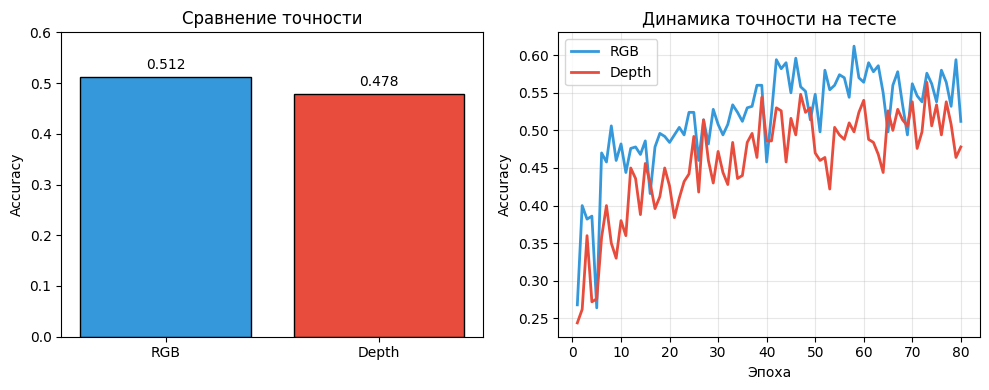

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


results = {
    'RGB': {'acc': hist_rgb['test_acc'][-1], 'loss': hist_rgb['test_loss'][-1]},
    'Depth': {'acc': hist_depth['test_acc'][-1], 'loss': hist_depth['test_loss'][-1]}
}


print(f"{'Модальность':<12} {'Accuracy':<12} {'Loss':<12}")
print("-" * 36)
for name, metrics in results.items():
    print(f"{name:<12} {metrics['acc']:.4f}        {metrics['loss']:.4f}")


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
modalities = ['RGB', 'Depth']
accuracies = [results[m]['acc'] for m in modalities]
bars = plt.bar(modalities, accuracies, color=['#3498db', '#e74c3c'], edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Сравнение точности')
plt.ylim(0, 0.6)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)


plt.subplot(1, 2, 2)
epochs = range(1, len(hist_rgb['test_acc']) + 1)
plt.plot(epochs, hist_rgb['test_acc'], label='RGB', color='#3498db', linewidth=2)
plt.plot(epochs, hist_depth['test_acc'], label='Depth', color='#e74c3c', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Динамика точности на тесте')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [1]:
"""
ВЫВОД:
Вообще мне очень понравился такой подход к созданию еще одной модальности, Наверное будет интересно для задачи с использованием лидара.
Интересно на каких данных авторы статьи обучали свою модель
Успешно сгенерированы синтетические depth-карты для сабсета STL10 с помощью Depth-Anything-3.
Обучены две идентичные CNN-ки, на RGB-изображениях и на depth-картах. - первая показала себя лучше но это не удивительно.
Интересно было бы использовать карты глубины именно в ДОПОЛНЕНИЕ к уже существующим данным. От этого точность явно не уменьшилась бы.
Подход зачетный, мне понравился
"""

'\nВЫВОД:\nВообще мне очень понравился такой подход к созданию еще одной модальности, Наверное будет интересно для задачи с использованием лидара. \nИнтересно на каких данных авторы статьи обучали свою модель \nУспешно сгенерированы синтетические depth-карты для сабсета STL10 с помощью Depth-Anything-3.\nОбучены две идентичные CNN-ки, на RGB-изображениях и на depth-картах. - первая показала себя лучше но это не удивительно.\nИнтересно было бы использовать карты глубины именно в ДОПОЛНЕНИЕ к уже существующим данным. От этого точность явно не уменьшилась бы.\nПодход зачетный, мне понравился\n'